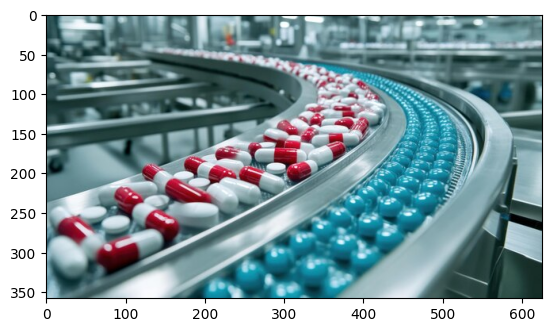

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = cv2.imread(r"C:\Users\HUAWEI\Documents\kapsul.jpg")
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
plt.imshow(image_rgb)
plt.show()

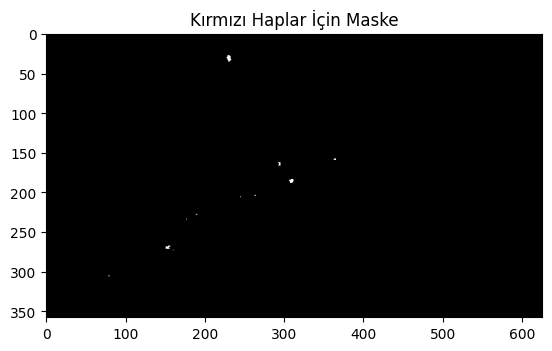

In [2]:
hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

lower_red = np.array([0, 120, 70])
upper_red = np.array([10, 255, 255])

mask = cv2.inRange(hsv, lower_red, upper_red)

plt.imshow(mask, cmap='gray')
plt.title("Kırmızı Haplar İçin Maske")
plt.show()

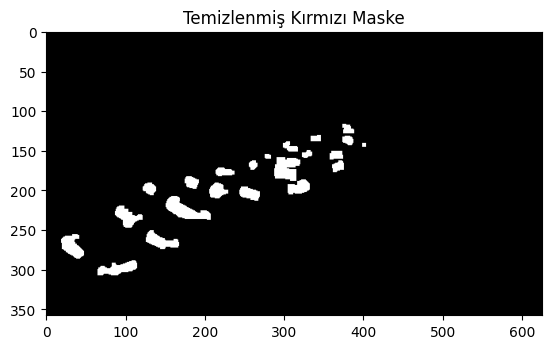

In [3]:
hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

lower_red1 = np.array([0, 120, 70])
upper_red1 = np.array([10, 255, 255])

lower_red2 = np.array([170, 120, 70])
upper_red2 = np.array([180, 255, 255])

mask1 = cv2.inRange(hsv, lower_red1, upper_red1)
mask2 = cv2.inRange(hsv, lower_red2, upper_red2)

mask = mask1 + mask2

kernel = np.ones((5,5), np.uint8)
mask_clean = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
plt.imshow(mask_clean, cmap='gray')
plt.title("Temizlenmiş Kırmızı Maske")
plt.show()

In [4]:
contours, _ = cv2.findContours(
    mask_clean,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

In [5]:
result = image.copy()

for cnt in contours:
    if cv2.contourArea(cnt) < 200:
        continue

    x,y,w,h = cv2.boundingRect(cnt)

    cv2.rectangle(result, (x,y), (x+w,y+h), (0,255,0), 2)
    cv2.putText(result, "Hap", (x,y-10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,255,0), 2)

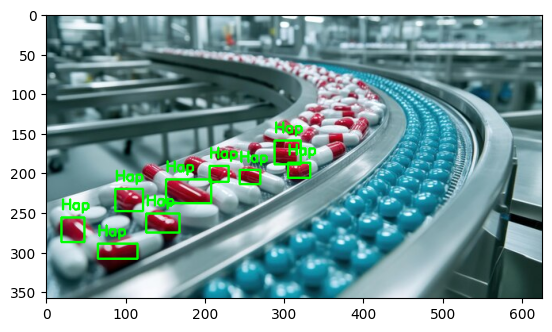

In [6]:
plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
plt.show()